In [1]:
# =========================
# 1. Set local paths
# =========================
import os

base_dir = r"C:\\Users\\Admin\\OneDrive\\Documents\\File_save_bai_tap_random\\Train"
train_dir = os.path.join(base_dir, "seg")
test_dir = os.path.join(base_dir, "seg_test")
sample_dir = os.path.join(base_dir, "sample")

best_model_path = os.path.join(base_dir, "best_model.h5")
history_phase1_path = os.path.join(base_dir, "history_phase1.csv")
history_finetune_path = os.path.join(base_dir, "history_finetune.csv")

In [2]:
import os

print(os.listdir(train_dir))

['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [3]:
# =========================
# 2. Import thư viện
# =========================
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras import layers, models, optimizers
import pandas as pd
import matplotlib.pyplot as plt
import os

In [4]:
# =========================
# 3. Cấu hình
# =========================
img_size = (224, 224)
batch_size = 32

In [5]:
print("GPU:", tf.config.list_physical_devices('GPU'))

GPU: []


In [6]:
# =========================
# 4. Data Generator
# =========================
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    subset="training"
)

val_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    subset="validation"
)

test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False
)

num_classes = train_gen.num_classes

Found 11230 images belonging to 6 classes.
Found 2804 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.


In [7]:
# =========================
# 5. Build Model (EfficientNetB0)
# =========================
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=img_size + (3,)
)

base_model.trainable = False

inputs = layers.Input(shape=img_size + (3,))
x = base_model(inputs, training=False)

x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)

outputs = layers.Dense(num_classes, activation="softmax")(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [8]:
# =========================
# 6. Callbacks
# =========================
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    best_model_path,
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

csv_logger = tf.keras.callbacks.CSVLogger(
    history_phase1_path,
    append=False
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [9]:
# =========================
# 7. Train (Phase 1)
# =========================
history = model.fit(
    train_gen,
    epochs=20,
    validation_data=val_gen,
    callbacks=[checkpoint, csv_logger, early_stop]
)

Epoch 1/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 449ms/step - accuracy: 0.3418 - loss: 2.0182
Epoch 1: val_accuracy improved from None to 0.82347, saving model to C:\\Users\\Admin\\OneDrive\\Documents\\File_save_bai_tap_random\\Train\best_model.h5



Epoch 1: finished saving model to C:\\Users\\Admin\\OneDrive\\Documents\\File_save_bai_tap_random\\Train\best_model.h5
351/351 ━━━━━━━━━━━━━━━━━━━━ 207s 577ms/step - accuracy: 0.5136 - loss: 1.4093 - val_accuracy: 0.8235 - val_loss: 0.5194
Epoch 2/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 452ms/step - accuracy: 0.7548 - loss: 0.6872
Epoch 2: val_accuracy improved from 0.82347 to 0.86769, saving model to C:\\Users\\Admin\\OneDrive\\Documents\\File_save_bai_tap_random\\Train\best_model.h5



Epoch 2: finished saving model to C:\\Users\\Admin\\OneDrive\\Documents\\File_save_bai_tap_random\\Train\best_model.h5
351/351 ━━━━━━━━━━━━━━━━━━━━ 197s 561ms/step - accuracy: 0.7744 - loss: 0.6297 - val_accuracy: 0.8677 - val_loss: 0.3721
Epoch 3/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 416ms/step - accuracy: 0.8149 - loss: 0.5189
Epoch 3: val_accuracy improved from 0.86769 to 0.87767, saving model to C:\\Users\\Admin\\OneDrive\\Documents\\File_save_bai_tap_random\\Train\best_model.h5



Epoch 3: finished saving model to C:\\Users\\Admin\\OneDrive\\Documents\\File_save_bai_tap_random\\Train\best_model.h5
351/351 ━━━━━━━━━━━━━━━━━━━━ 184s 524ms/step - accuracy: 0.8255 - loss: 0.4956 - val_accuracy: 0.8777 - val_loss: 0.3287
Epoch 4/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step - accuracy: 0.8476 - loss: 0.4396
Epoch 4: val_accuracy improved from 0.87767 to 0.89444, saving model to C:\\Users\\Admin\\OneDrive\\Documents\\File_save_bai_tap_random\\Train\best_model.h5



Epoch 4: finished saving model to C:\\Users\\Admin\\OneDrive\\Documents\\File_save_bai_tap_random\\Train\best_model.h5
351/351 ━━━━━━━━━━━━━━━━━━━━ 162s 461ms/step - accuracy: 0.8478 - loss: 0.4329 - val_accuracy: 0.8944 - val_loss: 0.2941
Epoch 5/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 379ms/step - accuracy: 0.8532 - loss: 0.4120
Epoch 5: val_accuracy improved from 0.89444 to 0.90193, saving model to C:\\Users\\Admin\\OneDrive\\Documents\\File_save_bai_tap_random\\Train\best_model.h5


...


Epoch 6: finished saving model to C:\\Users\\Admin\\OneDrive\\Documents\\File_save_bai_tap_random\\Train\best_model.h5
351/351 ━━━━━━━━━━━━━━━━━━━━ 188s 536ms/step - accuracy: 0.8699 - loss: 0.3768 - val_accuracy: 0.9051 - val_loss: 0.2658
Epoch 7/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 431ms/step - accuracy: 0.8712 - loss: 0.3599
Epoch 7: val_accuracy did not improve from 0.90514
351/351 ━━━━━━━━━━━━━━━━━━━━ 189s 538ms/step - accuracy: 0.8735 - loss: 0.3511 - val_accuracy: 0.9009 - val_loss: 0.2646
Epoch 8/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 423ms/step - accuracy: 0.8789 - loss: 0.3417
Epoch 8: val_accuracy did not improve from 0.90514
351/351 ━━━━━━━━━━━━━━━━━━━━ 186s 529ms/step - accuracy: 0.8785 - loss: 0.3411 - val_accuracy: 0.9051 - val_loss: 0.2580
Epoch 9/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 425ms/step - accuracy: 0.8794 - loss: 0.3430
Epoch 9: val_accuracy improved from 0.90514 to 0.90835, saving model to C:\\Users\\Admin\\OneDrive\\Documents\\File_save_bai_tap_random\\Train\best_mod


Epoch 9: finished saving model to C:\\Users\\Admin\\OneDrive\\Documents\\File_save_bai_tap_random\\Train\best_model.h5
351/351 ━━━━━━━━━━━━━━━━━━━━ 188s 535ms/step - accuracy: 0.8845 - loss: 0.3309 - val_accuracy: 0.9083 - val_loss: 0.2559
Epoch 10/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 482ms/step - accuracy: 0.8838 - loss: 0.3243
Epoch 10: val_accuracy improved from 0.90835 to 0.91476, saving model to C:\\Users\\Admin\\OneDrive\\Documents\\File_save_bai_tap_random\\Train\best_model.h5



Epoch 10: finished saving model to C:\\Users\\Admin\\OneDrive\\Documents\\File_save_bai_tap_random\\Train\best_model.h5
351/351 ━━━━━━━━━━━━━━━━━━━━ 222s 633ms/step - accuracy: 0.8848 - loss: 0.3177 - val_accuracy: 0.9148 - val_loss: 0.2440
Epoch 11/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 519ms/step - accuracy: 0.8891 - loss: 0.3161
Epoch 11: val_accuracy did not improve from 0.91476
351/351 ━━━━━━━━━━━━━━━━━━━━ 228s 649ms/step - accuracy: 0.8901 - loss: 0.3127 - val_accuracy: 0.9094 - val_loss: 0.2539
Epoch 12/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 480ms/step - accuracy: 0.8898 - loss: 0.3163
Epoch 12: val_accuracy improved from 0.91476 to 0.91548, saving model to C:\\Users\\Admin\\OneDrive\\Documents\\File_save_bai_tap_random\\Train\best_model.h5



Epoch 12: finished saving model to C:\\Users\\Admin\\OneDrive\\Documents\\File_save_bai_tap_random\\Train\best_model.h5
351/351 ━━━━━━━━━━━━━━━━━━━━ 210s 598ms/step - accuracy: 0.8924 - loss: 0.3019 - val_accuracy: 0.9155 - val_loss: 0.2305
Epoch 13/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 507ms/step - accuracy: 0.8956 - loss: 0.3042
Epoch 13: val_accuracy did not improve from 0.91548
351/351 ━━━━━━━━━━━━━━━━━━━━ 219s 624ms/step - accuracy: 0.8955 - loss: 0.2971 - val_accuracy: 0.9119 - val_loss: 0.2488
Epoch 14/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 483ms/step - accuracy: 0.8913 - loss: 0.2974
Epoch 14: val_accuracy did not improve from 0.91548
351/351 ━━━━━━━━━━━━━━━━━━━━ 214s 611ms/step - accuracy: 0.8929 - loss: 0.2944 - val_accuracy: 0.9141 - val_loss: 0.2366
Epoch 15/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 509ms/step - accuracy: 0.9052 - loss: 0.2655
Epoch 15: val_accuracy improved from 0.91548 to 0.92118, saving model to C:\\Users\\Admin\\OneDrive\\Documents\\File_save_bai_tap_random\\Train\b


Epoch 15: finished saving model to C:\\Users\\Admin\\OneDrive\\Documents\\File_save_bai_tap_random\\Train\best_model.h5
351/351 ━━━━━━━━━━━━━━━━━━━━ 220s 627ms/step - accuracy: 0.9004 - loss: 0.2764 - val_accuracy: 0.9212 - val_loss: 0.2256
Epoch 16/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 471ms/step - accuracy: 0.8988 - loss: 0.2731
Epoch 16: val_accuracy did not improve from 0.92118
351/351 ━━━━━━━━━━━━━━━━━━━━ 207s 589ms/step - accuracy: 0.8983 - loss: 0.2801 - val_accuracy: 0.9148 - val_loss: 0.2351
Epoch 17/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 462ms/step - accuracy: 0.9004 - loss: 0.2787
Epoch 17: val_accuracy did not improve from 0.92118
351/351 ━━━━━━━━━━━━━━━━━━━━ 202s 576ms/step - accuracy: 0.9012 - loss: 0.2760 - val_accuracy: 0.9148 - val_loss: 0.2265
Epoch 18/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 464ms/step - accuracy: 0.9087 - loss: 0.2583
Epoch 18: val_accuracy did not improve from 0.92118
351/351 ━━━━━━━━━━━━━━━━━━━━ 205s 583ms/step - accuracy: 0.9041 - loss: 0.2728 - val_accuracy

In [10]:
# =========================
# 8. Fine-tuning
# =========================
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

csv_logger_ft = tf.keras.callbacks.CSVLogger(
    history_finetune_path,
    append=False
)

history_ft = model.fit(
    train_gen,
    epochs=10,
    validation_data=val_gen,
    callbacks=[checkpoint, csv_logger_ft, early_stop]
)

Epoch 1/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 513ms/step - accuracy: 0.8076 - loss: 0.5190
Epoch 1: val_accuracy did not improve from 0.92118
351/351 ━━━━━━━━━━━━━━━━━━━━ 235s 636ms/step - accuracy: 0.8265 - loss: 0.4734 - val_accuracy: 0.9019 - val_loss: 0.2782
Epoch 2/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 511ms/step - accuracy: 0.8593 - loss: 0.3865
Epoch 2: val_accuracy did not improve from 0.92118
351/351 ━━━━━━━━━━━━━━━━━━━━ 220s 626ms/step - accuracy: 0.8618 - loss: 0.3788 - val_accuracy: 0.9066 - val_loss: 0.2644
Epoch 3/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 489ms/step - accuracy: 0.8698 - loss: 0.3618
Epoch 3: val_accuracy did not improve from 0.92118
351/351 ━━━━━━━━━━━━━━━━━━━━ 207s 591ms/step - accuracy: 0.8710 - loss: 0.3570 - val_accuracy: 0.9055 - val_loss: 0.2551
Epoch 4/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 462ms/step - accuracy: 0.8881 - loss: 0.3124
Epoch 4: val_accuracy did not improve from 0.92118
351/351 ━━━━━━━━━━━━━━━━━━━━ 198s 564ms/step - accuracy: 0.8861 - loss: 0.3190 - 

In [14]:
# =========================
# 8b. Lưu model cuối cùng (.h5)
# =========================
final_model_path = os.path.join(base_dir, "scene_efficientnetb0.h5")
model.save(final_model_path)
print("Saved final model to:", final_model_path)

Saved final model to: C:\\Users\\Admin\\OneDrive\\Documents\\File_save_bai_tap_random\\Train\scene_efficientnetb0.h5


In [11]:
# =========================
# 9. Evaluate
# =========================
test_loss, test_acc = model.evaluate(test_gen)
print("Test accuracy:", test_acc)

94/94 ━━━━━━━━━━━━━━━━━━━━ 33s 353ms/step - accuracy: 0.8963 - loss: 0.2933
Test accuracy: 0.8963333368301392


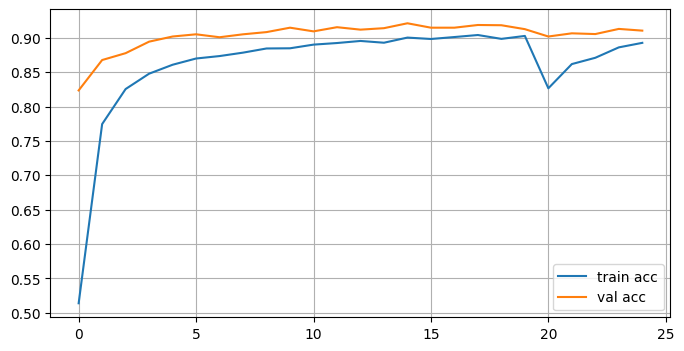

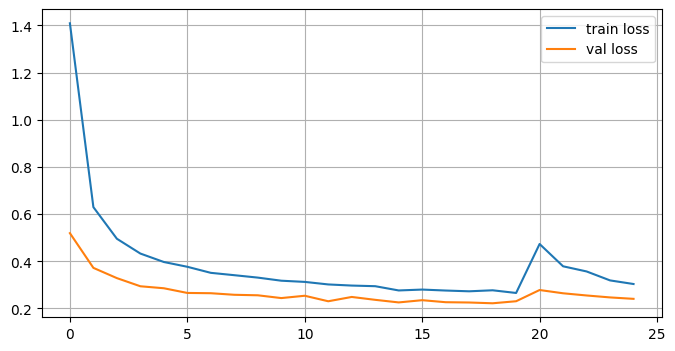

In [12]:
# =========================
# 10. Vẽ biểu đồ
# =========================
hist1 = pd.read_csv(history_phase1_path)
hist2 = pd.read_csv(history_finetune_path)

hist = pd.concat([hist1, hist2], ignore_index=True)

plt.figure(figsize=(8,4))
plt.plot(hist["accuracy"], label="train acc")
plt.plot(hist["val_accuracy"], label="val acc")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,4))
plt.plot(hist["loss"], label="train loss")
plt.plot(hist["val_loss"], label="val loss")
plt.legend()
plt.grid(True)
plt.show()

In [13]:
# =========================
# 11. Dự đoán ảnh mẫu
# =========================
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np

model = load_model(best_model_path)

class_indices = train_gen.class_indices
labels = dict((v, k) for k, v in class_indices.items())

for img_name in os.listdir(sample_dir):
    img_path = os.path.join(sample_dir, img_name)

    if not img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
        continue

    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)

    pred = model.predict(img_array)
    predicted_class = np.argmax(pred, axis=1)[0]

    print(f"{img_name}: {labels[predicted_class]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
296866297_2929633657.jpg: buildings
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
297024964_2926520320.jpg: buildings
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
298216354_2932688336.jpg: buildings
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
c0c9124a-vinh-ha-long-1.jpg: mountain
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
Duong-Pho-1.jpg: street
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
images (1).jpg: mountain
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
images (2).jpg: sea
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
images (3).jpg: sea
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
images (4).jpg: sea
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
images (5).jpg: street
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
images (6).jpg: street
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
images.jpg: mountain
